In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.tree import DecisionTreeRegressor
import joblib  # for saving the best model (optional deliverable)

# Plot style
plt.rcParams.update({'figure.dpi': 120, 'axes.spines.top': False,
                     'axes.spines.right': False, 'font.size': 11})
print("✅ All libraries imported successfully!")

✅ All libraries imported successfully!


In [3]:
import pandas as pd
from sklearn.datasets import fetch_california_housing

# Load directly from sklearn — no CSV needed
# Step 2: Load Dataset
data = fetch_california_housing(as_frame=True)
df = pd.concat([data.data, data.target.rename("HousePrice")], axis=1)

print("Dataset shape:", df.shape)
print("Features:", list(data.feature_names))
print("Target: HousePrice (Median House Value in $100k)")
df.head()

Dataset shape: (20640, 9)
Features: ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']
Target: HousePrice (Median House Value in $100k)


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,HousePrice
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [4]:
# Step 3: Separate Features and Target
X = df.drop("HousePrice", axis=1)
y = df["HousePrice"]

print("Features shape:", X.shape)
print("Target shape:", y.shape)

# Step 4: Feature Scaling (Critical Step)
# Fit scaler ONLY on X — before splitting, to normalize all features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("\n✅ Feature scaling applied!")
print("Mean of scaled features (should be ~0):", X_scaled.mean(axis=0).round(2))

Features shape: (20640, 8)
Target shape: (20640,)

✅ Feature scaling applied!
Mean of scaled features (should be ~0): [ 0.  0.  0. -0. -0.  0.  0. -0.]


In [5]:
# Step 5: Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

print("Training samples:", X_train.shape[0])
print("Testing samples :", X_test.shape[0])
print("\n✅ Data split complete — 80% train, 20% test")

Training samples: 16512
Testing samples : 4128

✅ Data split complete — 80% train, 20% test


In [8]:
# Step 6: Train Multiple Models and Evaluate
models = {
    "Linear Regression": LinearRegression(),
    "Ridge Regression": Ridge(alpha=1.0),
    "Decision Tree": DecisionTreeRegressor(max_depth=5)
}

results = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    predictions = model.predict(X_test)
    
    rmse = np.sqrt(mean_squared_error(y_test, predictions))  # fixed for sklearn 1.8+
    r2   = r2_score(y_test, predictions)
    
    results[name] = {"RMSE": round(rmse, 4), "R² Score": round(r2, 4)}
    print(f"{name:25s} → RMSE: {rmse:.4f} | R²: {r2:.4f}")

# Model Comparison Table
print("\n--- Model Performance Comparison Table ---")
results_df = pd.DataFrame(results).T
print(results_df)

Linear Regression         → RMSE: 0.7456 | R²: 0.5758
Ridge Regression          → RMSE: 0.7456 | R²: 0.5758
Decision Tree             → RMSE: 0.7242 | R²: 0.5997

--- Model Performance Comparison Table ---
                     RMSE  R² Score
Linear Regression  0.7456    0.5758
Ridge Regression   0.7456    0.5758
Decision Tree      0.7242    0.5997


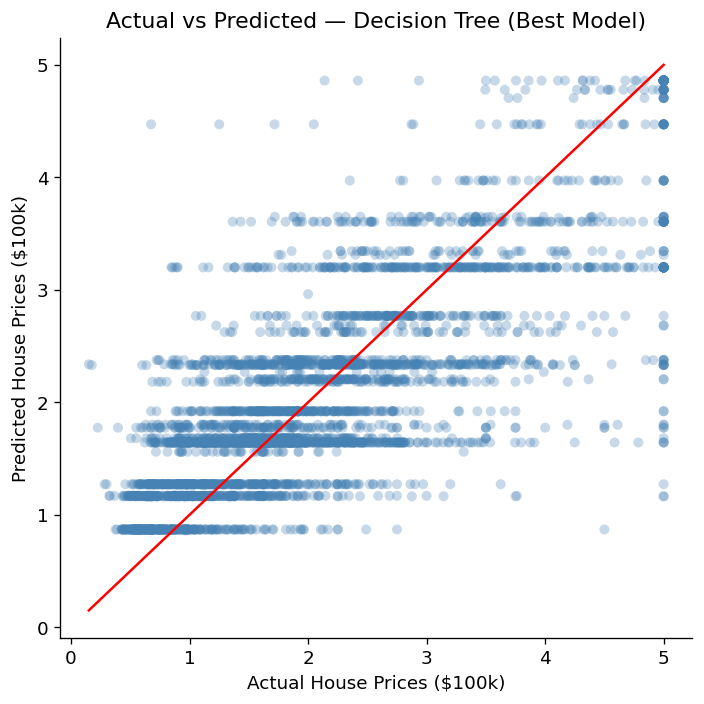

In [9]:
# Step 7: Visual Performance Validation — Best Model (Decision Tree)
best_model = models["Decision Tree"]
y_pred = best_model.predict(X_test)

plt.figure(figsize=(6, 6))
plt.scatter(y_test, y_pred, alpha=0.3, color='steelblue', edgecolors='none')
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()], color='red', linewidth=1.5)
plt.xlabel("Actual House Prices ($100k)")
plt.ylabel("Predicted House Prices ($100k)")
plt.title("Actual vs Predicted — Decision Tree (Best Model)")
plt.tight_layout()
plt.show()

In [10]:
# Step 8: Save the Best Model using joblib
import os
os.makedirs("saved_model_task2", exist_ok=True)

joblib.dump(best_model, "saved_model_task2/decision_tree_model.pkl")
joblib.dump(scaler, "saved_model_task2/scaler.pkl")

print("✅ Best model saved → saved_model_task2/decision_tree_model.pkl")
print("✅ Scaler saved    → saved_model_task2/scaler.pkl")

✅ Best model saved → saved_model_task2/decision_tree_model.pkl
✅ Scaler saved    → saved_model_task2/scaler.pkl
